In [3]:
# save pdf figures so that text is editable in AI
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

### Load in cell-by-gene matrix

In [4]:
import pandas as pd
import numpy as np

# load cell-by-gene matrix
enhancer_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_enhancer_transcripts_unfiltered_cbg_drift_corrected.csv')
T7_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_spots_unfiltered_cbg.csv')
# enhancer_cbg_rep = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\Sept_2024_enhancers_cbg_clean_drift_corrected.csv')
# T7_cbg_rep = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\Sept_2024_T7_transcript_cbg_clean_drift_corrected.csv')
# norm_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_normalized_cbg.csv')
# log2_FC = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_log2_FC_cbg.csv')

### Check the detection frequency of each enhancer/T7 transcript across all cells

In [5]:
cre_presence = []

for cre in T7_cbg.columns[1:21]:
    present = T7_cbg[cre] > 0
    present_ = present.sum()
    present__ = present_/len(T7_cbg)
    cre_presence.append(present__)

cre_presence.insert(0, 'percent detected')
cre_names = [cre for cre in T7_cbg.columns[:21]]
cbg = T7_cbg.filter(cre_names, axis=1)
cbg.loc[cbg.index.max() + 1, :] = cre_presence

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_42916\3369258976.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'percent detected' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cbg.loc[cbg.index.max() + 1, :] = cre_presence


Text(0, 0.5, 'No. of T7-derived barcodes')

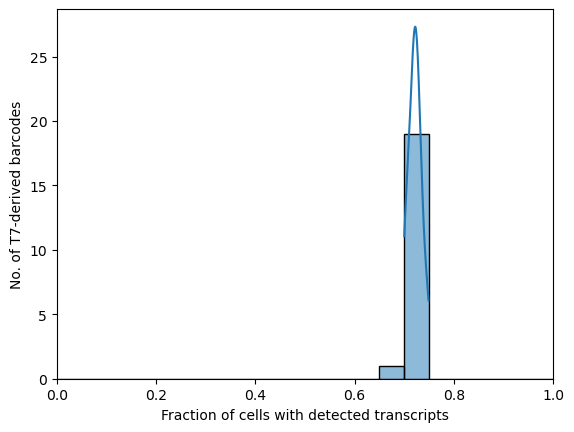

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
ax = sns.histplot(x=cbg.iloc[-1,1:21], binwidth=0.05, binrange=(0,1), legend=False, kde=True)
ax.set_xlim(0,1)
ax.set_xlabel('Fraction of cells with detected transcripts')
ax.set_ylabel('No. of T7-derived barcodes')
# ax.set_title('T7 transcripts')
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_detection_stats_240816.pdf')

([], [])

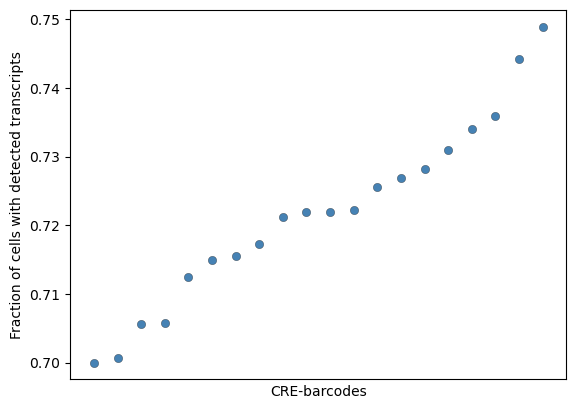

In [7]:
fig, ax = plt.subplots()
ax = sns.scatterplot(x=range(0,20),y=np.sort(cbg.iloc[-1,1:21]), facecolor='steelblue', edgecolor='k', lw=0.2)
ax.set_xlim(-1,20)
ax.set_xlabel('CRE-barcodes')
ax.set_ylabel('Fraction of cells with detected transcripts')
plt.xticks([])
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/fraction_of_cells_transcript_detected_scatterplot_240504', dpi=450)

In [13]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020']

enhancers = ['E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08',
        'E09', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16',
        'E17', 'E18', 'E19', 'E20']

test_CREs = [0,4,8,10,13,
 156,212,367,594,746,
 1339,1297,1283,1276,1306,
 7435,7467,7474,7507,7521]

STARRseq = pd.read_csv(r'C:\Users\zgibbs\cellpose\RNAvsDNA.edgeR.csv')
a = STARRseq['genes'].loc[test_CREs]

CRE_names = dict(zip(CREs, a))
enhancer_names = dict(zip(CREs, enhancers))

### Actually normalize the enhancer counts by T7 counts

In [9]:
# merge the enhancer and T7 counts
merged = pd.merge(enhancer_cbg, T7_cbg, how='left', left_on='masks', right_on='masks')
# merged_rep = pd.merge(enhancer_cbg_rep, T7_cbg_rep, how='left', left_on='masks', right_on='masks')

In [14]:
# divide enhancer counts by T7 counts in merged cbg matrix
for cre in CREs:
    idx = str(cre + '_x')
    idy = str(cre + '_y')
    merged[cre] = merged[idx] / merged[idy]
    # merged_rep[cre] = merged_rep[idx] / merged_rep[idy]

In [15]:
# fill inf and nan with zeroes, creating a new merged dataframe
merged.replace([np.inf, -np.inf], np.nan, inplace=True)
merged_ = merged.iloc[:,-20:].fillna(0)

# add total normalized transcripts per cell, and add mask ids & fov labels
merged_['total transcripts'] = merged_.iloc[:,:20].sum(axis=1)
merged_['masks'] = merged['masks']
merged_['fov'] = pd.cut(merged.index.astype(int), bins = np.arange(0, 185)*1000, right=False)

In [10]:
# fill inf and nan with zeroes, creating a new merged dataframe
merged_rep.replace([np.inf, -np.inf], np.nan, inplace=True)
merged_rep_ = merged_rep.iloc[:,-20:].fillna(0)

# add total normalized transcripts per cell, and add mask ids & fov labels
merged_rep_['total transcripts'] = merged_rep_.iloc[:,:20].sum(axis=1)
merged_rep_['masks'] = merged_rep['masks']
merged_rep_['fov'] = pd.cut(merged_rep.index.astype(int), bins = np.arange(0, 185)*1000, right=False)

In [16]:
merged_.columns[:20]

Index(['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007',
       'CRE008', 'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014',
       'CRE015', 'CRE016', 'CRE017', 'CRE018', 'CRE019', 'CRE020'],
      dtype='object')

### Linear regression analysis of data +/- T7 normalization

In [137]:
# all_cbg['blanks'] = all_cbg_rep1.loc[:, 'blank0000':'blank0166'].mean(axis=1)
# all_cbg_rep2['blanks'] = all_cbg_rep2.loc[:, 'blank0000':'blank0166'].mean(axis=1)

In [9]:
# all_cbg['total transcripts'] = all_cbg.iloc[:,1:21].sum(axis=1)
# all_cbg_rep2['total transcripts'] = all_cbg_rep2.iloc[:,1:21].sum(axis=1)

In [17]:
from scipy import stats

enhancer_rep1 = []

for cre in enhancer_cbg.columns[1:21]:
    res = stats.linregress(enhancer_cbg['total transcripts'], enhancer_cbg[cre])
    enhancer_rep1.append(res)

In [13]:
from scipy import stats

enhancer_rep2 = []

for cre in enhancer_cbg_rep.columns[1:21]:
    res = stats.linregress(enhancer_cbg_rep['total transcripts'], enhancer_cbg_rep[cre])
    enhancer_rep2.append(res)

In [18]:
from scipy import stats

T7_rep1 = []

for cre in T7_cbg.columns[1:21]:
    res = stats.linregress(T7_cbg['total transcripts'], T7_cbg[cre])
    T7_rep1.append(res)

In [15]:
from scipy import stats

T7_rep2 = []

for cre in T7_cbg_rep.columns[1:21]:
    res = stats.linregress(T7_cbg_rep['total transcripts'], T7_cbg_rep[cre])
    T7_rep2.append(res)

In [19]:
from scipy import stats

norm_rep1 = []

for cre in merged_.columns[:20]:
    res = stats.linregress(merged_['total transcripts'], merged_[cre])
    norm_rep1.append(res)

In [17]:
from scipy import stats

norm_rep2 = []

for cre in merged_rep_.columns[:20]:
    res = stats.linregress(merged_rep_['total transcripts'], merged_rep_[cre])
    norm_rep2.append(res)

In [21]:
y = [enhancer_rep1[i].slope for i in range(20)]
y2 = [T7_rep1[i].slope for i in range(20)]
# y3 = [enhancer_rep2[i].slope for i in range(20)]
# y4 = [T7_rep2[i].slope for i in range(20)]
y5 = [norm_rep1[i].slope for i in range(20)]
# y6 = [norm_rep2[i].slope for i in range(20)]

In [22]:
yerr = [enhancer_rep1[i].stderr*1.96 for i in range(20)]
yerr2 = [T7_rep1[i].stderr*1.96 for i in range(20)]
# yerr3 = [enhancer_rep2[i].stderr*1.96 for i in range(20)]
# yerr4 = [T7_rep2[i].stderr*1.96 for i in range(20)]
yerr5 = [norm_rep1[i].stderr*1.96 for i in range(20)]
# yerr6 = [norm_rep2[i].stderr*1.96 for i in range(20)]

In [23]:
enhancer_full_rep1 = pd.DataFrame(list(zip(enhancer_cbg.columns[1:21], y, yerr)), columns = ['id', 'score', 'stderr'])
T7_full_rep1 = pd.DataFrame(list(zip(T7_cbg.columns[1:21], y2, yerr2)), columns = ['id', 'score', 'stderr'])
# enhancer_full_rep2 = pd.DataFrame(list(zip(enhancer_cbg_rep.columns[1:21], y3, yerr3)), columns = ['id', 'score', 'stderr'])
# T7_full_rep2 = pd.DataFrame(list(zip(T7_cbg_rep.columns[1:21], y4, yerr4)), columns = ['id', 'score', 'stderr'])
norm_full_rep1 = pd.DataFrame(list(zip(enhancer_cbg.columns[1:21], y5, yerr5)), columns = ['id', 'score', 'stderr'])
# norm_full_rep2 = pd.DataFrame(list(zip(enhancer_cbg_rep.columns[1:21], y6, yerr6)), columns = ['id', 'score', 'stderr'])

In [25]:
enhancer_full_rep1_s = enhancer_full_rep1.sort_values('score', axis=0, ascending=False)
T7_full_rep1_s = T7_full_rep1.sort_values('score', axis=0, ascending=False)
# enhancer_full_rep2_s = enhancer_full_rep2.sort_values('score', axis=0, ascending=False)
# T7_full_rep2_s = T7_full_rep2.sort_values('score', axis=0, ascending=False)
norm_full_rep1_s = norm_full_rep1.sort_values('score', axis=0, ascending=False)
# norm_full_rep2_s = norm_full_rep2.sort_values('score', axis=0, ascending=False)

In [26]:
# plotcomps = {'enhancer_full_rep1_s':enhancer_full_rep1_s, 'T7_full_rep1_s':T7_full_rep1_s, 'norm_full_rep1_s':norm_full_rep1_s,
#              'enhancer_full_rep2_s':enhancer_full_rep2_s, 'T7_full_rep2_s':T7_full_rep2_s, 'norm_full_rep2_s':norm_full_rep2_s}

plotcomps = {'enhancer_full_rep1_s':enhancer_full_rep1_s, 'T7_full_rep1_s':T7_full_rep1_s, 'norm_full_rep1_s':norm_full_rep1_s}

In [27]:
norm_full_rep1_s

,id,score,stderr
2,CRE003,0.148154,0.001910
4,CRE005,0.122726,0.001928
0,CRE001,0.117379,0.001334
12,CRE013,0.101904,0.001283
17,CRE018,0.074577,0.000968
3,CRE004,0.060352,0.000773
1,CRE002,0.059721,0.000837
19,CRE020,0.054941,0.001103
6,CRE007,0.041525,0.000523
5,CRE006,0.041051,0.001502


### Plot the T7 and enhancer activity (regression) scores +/- normalization

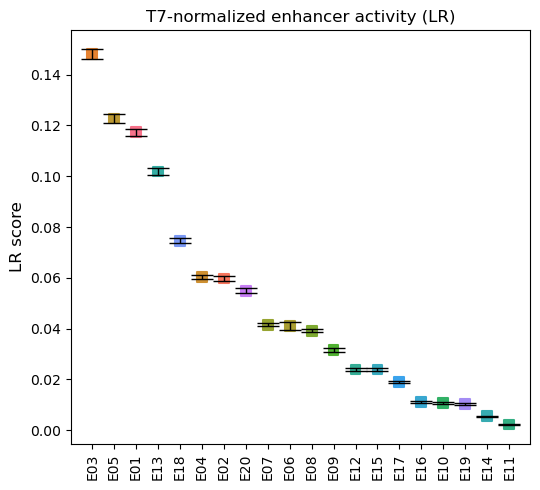

In [29]:
fig, ax = plt.subplots(figsize=(5.5,5))

ax.scatter(np.arange(20), norm_full_rep1_s['score'], marker='s', c=[colors[idx] for idx in norm_full_rep1_s['id']], s=50, lw=1.5)
ax.errorbar(np.arange(20), norm_full_rep1_s['score'], norm_full_rep1_s['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')

ax.set_xticks(np.arange(20))
ax.set_ylabel('LR score', fontsize=12)
ax.set_title('T7-normalized enhancer activity (LR)')
ax.set_xlabel(None)
ax.set_xticklabels([enhancer_names[idx] for idx in norm_full_rep1_s['id']], rotation=90)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_LR_with_T7_normalization_250131.pdf')

plt.show()

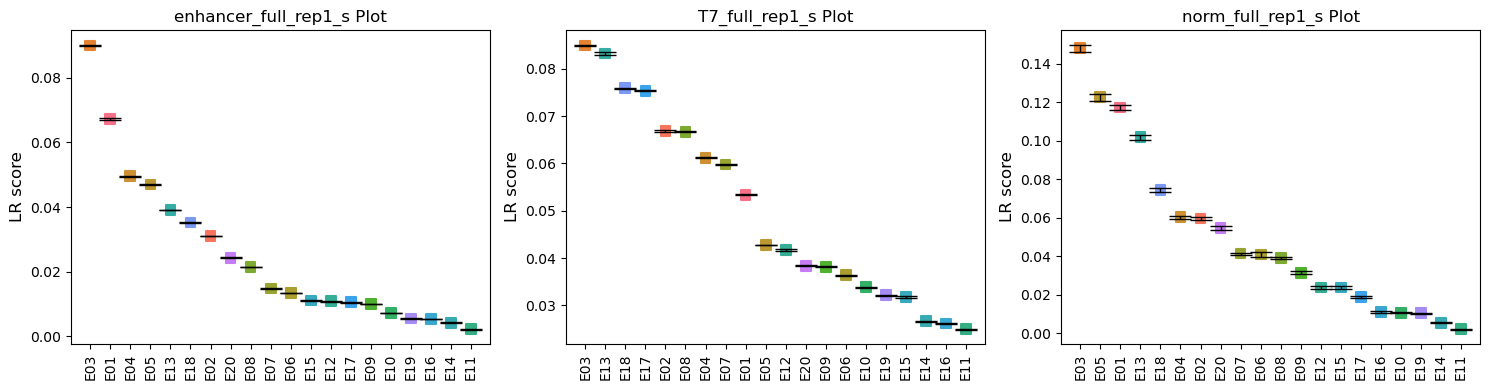

In [33]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(1, 3, figsize=(15,4))

# Flatten the ax array to easily loop through each subplot
ax = ax.flatten()

for i, (name, df) in enumerate(plotcomps.items()):
    # Plot on the i-th subplot
    ax[i].scatter(np.arange(20), df['score'], marker='s', c=[colors[idx] for idx in df['id']], s=50, lw=1.5)
    ax[i].errorbar(np.arange(20), df['score'], df['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
    
    ax[i].set_xticks(np.arange(20))
    ax[i].set_ylabel('LR score', fontsize=12)
    ax[i].set_title(f"{name} Plot")
    ax[i].set_xlabel(None)
    ax[i].set_xticklabels([enhancer_names[idx] for idx in df['id']], rotation=90)

    # numcells = len(df)
    # anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
    # ax[i].add_artist(anchored_text)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\activity_no_T7_normalization_241003.pdf')
plt.show()

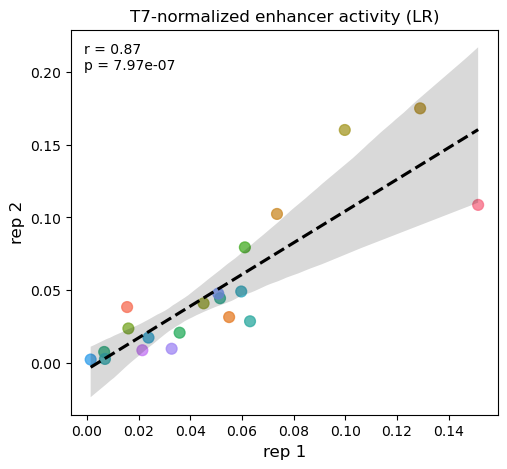

In [208]:
# plot the correlation between linear regression scores

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = norm_full_rep1['score']
y = norm_full_rep2['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in norm_full_rep1['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('rep 2', fontsize=12)
ax.set_xlabel('rep 1', fontsize=12)
ax.set_title('T7-normalized enhancer activity (LR)')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_Sept_2024_analysis\T7_normalized_enhancer_LR_reps_pearson_corr_250131.pdf')
plt.show()

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_2868\3932365021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = merged_.groupby('fov').mean()
C:\Users\zgibbs\AppData\Local\Temp\ipykernel_2868\3932365021.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]],


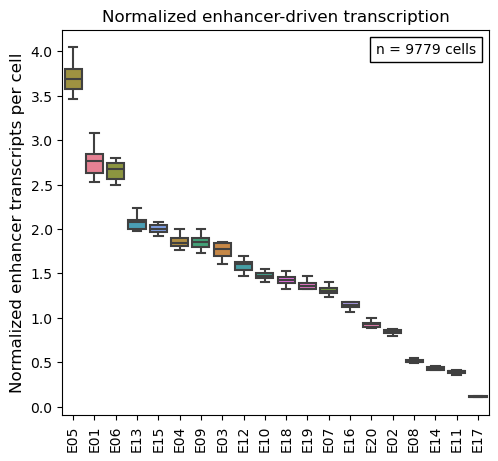

In [57]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = merged_.groupby('fov').mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]],
                linewidth=1.5, showfliers=False, order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('Normalized enhancer transcripts per cell', fontsize=12)
ax.set_title('Normalized enhancer-driven transcription')

numcells = len(merged_)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\normalized_enhancer_tpc_241003.pdf')
plt.show()

In [95]:
np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_31516\1467137492.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)


array([2.75377018, 0.84337723, 1.7591851 , 1.87420404, 3.69830868,
       2.6555178 , 1.30200776, 0.51317924, 1.84987839, 1.47620298,
       0.39525592, 1.5902238 , 2.07044301, 0.43680245, 2.00296997,
       1.14122523, 0.11310581, 1.42430843, 1.35989569, 0.92881392])

In [90]:
merged

,masks,CRE001_x,CRE002_x,CRE003_x,CRE004_x,CRE005_x,CRE006_x,CRE007_x,CRE008_x,CRE009_x,...,CRE011,CRE012,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020
0,10,12,7,17,7,36,9,4,4,7,...,0.000000,1.000000,0.266667,0.000000,1.400000,0.285714,0.020270,0.350000,0.50,0.090909
1,11,3,0,7,6,19,5,3,0,0,...,0.000000,0.000000,3.500000,0.000000,4.000000,NaN,0.000000,1.666667,NaN,1.000000
2,12,10,2,32,6,22,10,2,3,5,...,NaN,0.571429,0.421053,0.000000,1.400000,0.000000,0.000000,0.352941,1.00,0.200000
3,13,9,11,41,14,71,17,6,3,12,...,0.000000,0.937500,0.300000,0.117647,1.857143,1.000000,0.000000,0.306122,0.75,0.058824
4,15,3,3,8,4,6,6,2,0,5,...,NaN,1.500000,0.285714,NaN,5.000000,NaN,0.000000,1.000000,1.50,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9774,224057,6,7,9,4,17,17,5,4,12,...,NaN,NaN,3.000000,0.000000,NaN,0.000000,0.000000,2.200000,NaN,1.000000
9775,224058,6,5,7,2,33,11,2,3,9,...,3.000000,6.000000,3.500000,0.500000,3.000000,1.500000,0.025974,1.000000,3.00,0.666667
9776,224060,9,8,13,15,36,25,13,11,15,...,1.142857,2.125000,2.250000,1.428571,2.125000,2.400000,0.115789,2.000000,1.25,1.214286
9777,224062,0,3,0,3,14,6,3,0,2,...,NaN,NaN,1.500000,0.000000,NaN,0.000000,0.000000,NaN,3.00,0.333333


C:\Users\zgibbs\AppData\Local\Temp\ipykernel_31516\1312425910.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)
C:\Users\zgibbs\AppData\Local\Temp\ipykernel_31516\1312425910.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y = np.nanmean([merged_rep_.groupby('fov')[i].mean() for i in merged_rep_.columns[:-3]], axis=1)


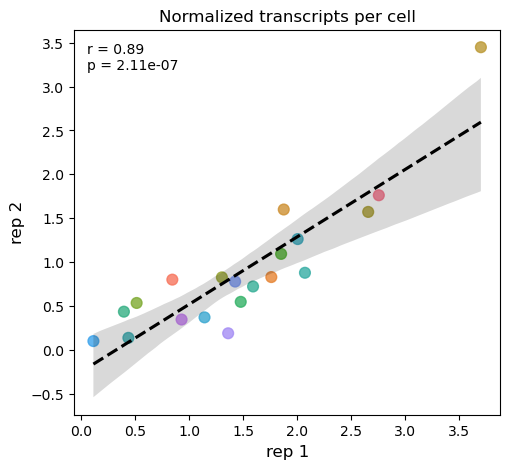

In [164]:
# plot the correlation between normalized transcripts per cell (no regression)

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)
y = np.nanmean([merged_rep_.groupby('fov')[i].mean() for i in merged_rep_.columns[:-3]], axis=1)

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in merged_.columns[:-3]], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('rep 2', fontsize=12)
ax.set_xlabel('rep 1', fontsize=12)
ax.set_title('Normalized transcripts per cell')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_Sept_2024_analysis\enhancer_tpc_normalized_reps_pearson_corr_241003.pdf')
plt.show()

### Plot correlations between activity scores or raw counts

In [411]:
no_outlier = [False if i == 'CRE005' else True for i in norm_full['id']]

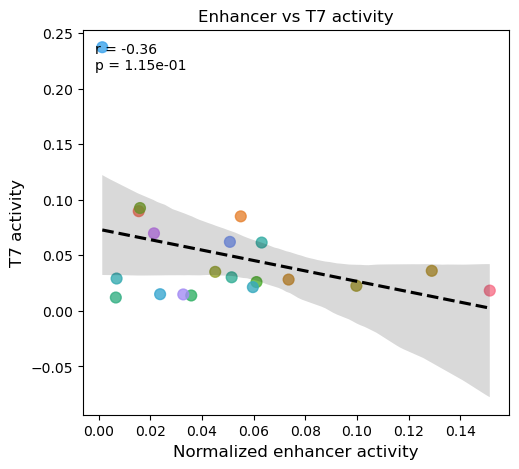

In [740]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = norm_full['score']
y = T7_full['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in norm_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('T7 activity', fontsize=12)
ax.set_xlabel('Normalized enhancer activity', fontsize=12)
ax.set_title('Enhancer vs T7 activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\norm_enhancer_vs_T7_activity_corr_240828.pdf')
plt.show()

In [87]:
CRE_means

masks                111207.020536
CRE001                   33.313687
CRE002                   18.844432
CRE003                   48.403466
CRE004                   24.403657
CRE005                   33.625291
CRE006                   12.983374
CRE007                   10.777523
CRE008                   12.896271
CRE009                   10.327074
CRE010                    6.805629
CRE011                    2.899661
CRE012                    9.926093
CRE013                   24.267191
CRE014                    4.504583
CRE015                   10.974822
CRE016                    5.340130
CRE017                    7.278604
CRE018                   21.354530
CRE019                    5.748346
CRE020                   16.207899
total transcripts       641.764533
dtype: float64

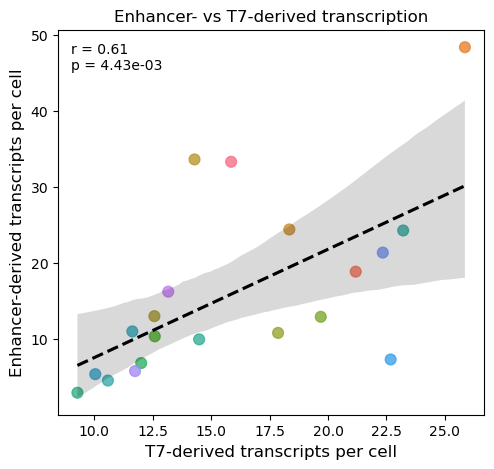

In [88]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

T7 = T7_cbg.groupby('fov').mean()
T7_means = T7.mean(axis=0)

CRE = enhancer_cbg.groupby('fov').mean()
CRE_means = CRE.mean(axis=0)

x =T7_means[1:21]
y = CRE_means[1:21]

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in CRE_means[1:21].index], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('Enhancer-derived transcripts per cell', fontsize=12)
ax.set_xlabel('T7-derived transcripts per cell', fontsize=12)
ax.set_title('Enhancer- vs T7-derived transcription')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_vs_T7_tpc_corr_240828.pdf')
plt.show()

### Plot the raw T7 and enhancer (+/- normalization) counts per cell (per FOV)

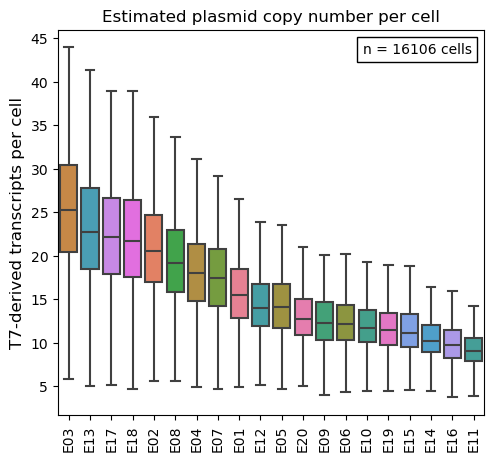

In [34]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = T7_cbg.groupby('fov').mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([T7_cbg.groupby('fov')[i].mean() for i in T7_cbg.columns[1:-2]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
            order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('T7-derived transcripts per cell', fontsize=12)
ax.set_title('Estimated plasmid copy number per cell')

numcells = len(T7_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_241003.pdf')
plt.show()

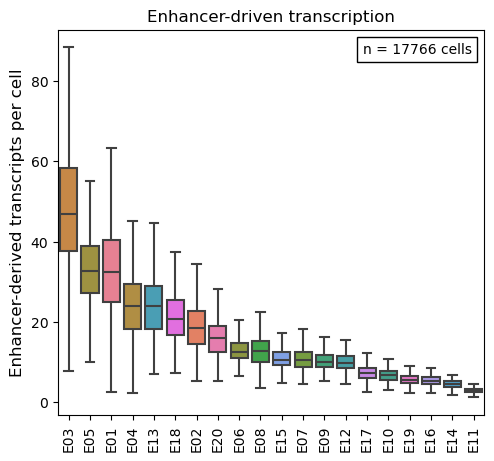

In [35]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = enhancer_cbg.groupby('fov').mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([enhancer_cbg.groupby('fov')[i].mean() for i in enhancer_cbg.columns[1:-2]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
           order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('Enhancer-derived transcripts per cell', fontsize=12)
ax.set_title('Enhancer-driven transcription')

numcells = len(enhancer_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_tpc_241003.pdf')
plt.show()

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_42916\1045326841.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = merged_.groupby('fov').mean()
C:\Users\zgibbs\AppData\Local\Temp\ipykernel_42916\1045326841.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]],


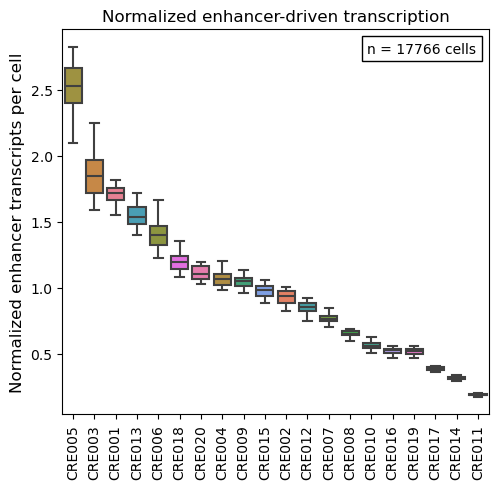

In [38]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = merged_.groupby('fov').mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]],
                linewidth=1.5, showfliers=False, order=sort_order)
plt.xticks(np.arange(20), sort_order, rotation=90);
ax.set_ylabel('Normalized enhancer transcripts per cell', fontsize=12)
ax.set_title('Normalized enhancer-driven transcription')

numcells = len(merged_)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\normalized_enhancer_tpc_240828.pdf')
plt.show()

### Look at plasmid library complexity vs imaging data

In [40]:
import pandas as pd

SFv4_T7_counts = pd.read_table(r'C:\Users\zgibbs\cellpose\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_2_sample_2_counts', sep='\s+', header=None, index_col=None)
SFv4_T7_counts.iloc[:, [0, 1]] = SFv4_T7_counts.iloc[:, [1, 0]]
SFv4_T7_counts.columns = ['id', 'counts']
SFv4_T7_counts['cpm'] = (SFv4_T7_counts['counts'].div(np.sum(SFv4_T7_counts['counts'])))*1000000 

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_42916\772443015.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     CRE001
1     CRE002
2     CRE003
3     CRE004
4     CRE005
5     CRE006
6     CRE007
7     CRE008
8     CRE009
9     CRE010
10    CRE011
11    CRE012
12    CRE013
13    CRE014
14    CRE015
15    CRE016
16    CRE017
17    CRE018
18    CRE019
19    CRE020
Name: 1, dtype: object' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  SFv4_T7_counts.iloc[:, [0, 1]] = SFv4_T7_counts.iloc[:, [1, 0]]


In [41]:
SFv4_T7_counts

,id,counts,cpm
0,CRE001,47348,49915.924749
1,CRE002,206662,217870.339622
2,CRE003,131420,138547.580267
3,CRE004,16133,17007.975289
4,CRE005,47419,49990.775443
5,CRE006,918,967.787846
6,CRE007,92878,97915.250038
7,CRE008,32475,34236.285719
8,CRE009,3133,3302.91865
9,CRE010,3383,3566.477431


In [42]:
# make new dataframe of raw enhancer transcripts per cell
enh = enhancer_cbg.groupby('fov').mean()
enh_means = enh.mean(axis=0)
enh_means_df = pd.DataFrame(zip(CREs, enh_means[1:21]), columns=['id', 'counts'])
enh_means_df['normalized'] = enh_means_df['counts'].div(SFv4_T7_counts['counts'])

# enh_rep = enhancer_cbg_rep.groupby('fov').mean()
# enh_rep_means = enh_rep.mean(axis=0)
# enh_rep_means_df = pd.DataFrame(zip(CREs, enh_rep_means[1:21]), columns=['id', 'counts'])
# enh_rep_means_df['normalized'] = enh_rep_means_df['counts'].div(SFv4_T7_counts['counts'])

# make new dataframe of raw T7 transcripts per cell
T7 = T7_cbg.groupby('fov').mean()
T7_means = T7.mean(axis=0)
T7_means_df = pd.DataFrame(zip(CREs, T7_means[1:21]), columns=['id', 'counts'])

# T7_rep = T7_cbg_rep.groupby('fov').mean()
# T7_rep_means = T7_rep.mean(axis=0)
# T7_rep_means_df = pd.DataFrame(zip(CREs, T7_rep_means[1:21]), columns=['id', 'counts'])

In [321]:
# create versions of the dfs that lack CRE017 data
SFv4_T7_counts_dropped = SFv4_T7_counts.drop(16)
SFv4_T7_counts_dropped.reset_index(drop=True, inplace=True)

enh_means_df_dropped = enh_means_df.drop(16)
enh_means_df_dropped.reset_index(drop=True, inplace=True)

enh_rep_means_df_dropped = enh_rep_means_df.drop(16)
enh_rep_means_df_dropped.reset_index(drop=True, inplace=True)

T7_means_df_dropped = T7_means_df.drop(16)
T7_means_df_dropped.reset_index(drop=True, inplace=True)

T7_rep_means_df_dropped = T7_rep_means_df.drop(16)
T7_rep_means_df_dropped.reset_index(drop=True, inplace=True)

In [350]:
enh_means_df['normalized'] = enh_means_df['counts'] * (SFv4_T7_counts['norm'])

In [47]:
T7_means_df

,id,counts
0,CRE001,15.854926
1,CRE002,21.185497
2,CRE003,25.857115
3,CRE004,18.344374
4,CRE005,14.286997
5,CRE006,12.570742
6,CRE007,17.863067
7,CRE008,19.689786
8,CRE009,12.587617
9,CRE010,12.006035


In [44]:
# create new dfs of total FISH spots for enhancer/T7-driven transcripts
T7_imaging = pd.DataFrame(zip(CREs, T7_cbg.iloc[:,1:21].sum()), columns=['id', 'spots'])
enh_imaging = pd.DataFrame(zip(CREs, enhancer_cbg.iloc[:,1:21].sum()), columns=['id', 'spots'])

In [45]:
enh_imaging

,id,spots
0,CRE001,589231
1,CRE002,331327
2,CRE003,854763
3,CRE004,431254
4,CRE005,591254
5,CRE006,226521
6,CRE007,188506
7,CRE008,227366
8,CRE009,180141
9,CRE010,118183


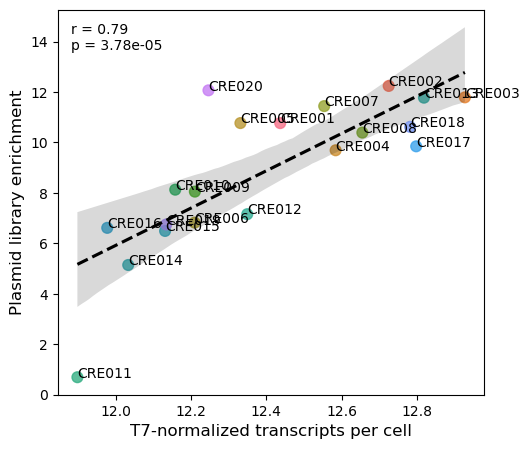

In [49]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

# x = np.log(T7_rep_means_df['counts'])
x = np.log(T7_imaging['spots'])
y = np.log(SFv4_T7_counts['counts'].astype(float))

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in SFv4_T7_counts['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('Plasmid library enrichment', fontsize=12)
ax.set_xlabel('T7-normalized transcripts per cell', fontsize=12)
# ax.set_title('Plasmid library bias vs T7-derived transcription')

# add labels to each point on the scatter plot
for i, txt in enumerate(SFv4_T7_counts['id']):
    ax.annotate(txt, (x[i], y[i]))


stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\plasmid_enrichment_vs_enhancerrep2_LR_corr_log_250228.pdf')
plt.show()

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_42916\4163500167.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  T7norm = np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)


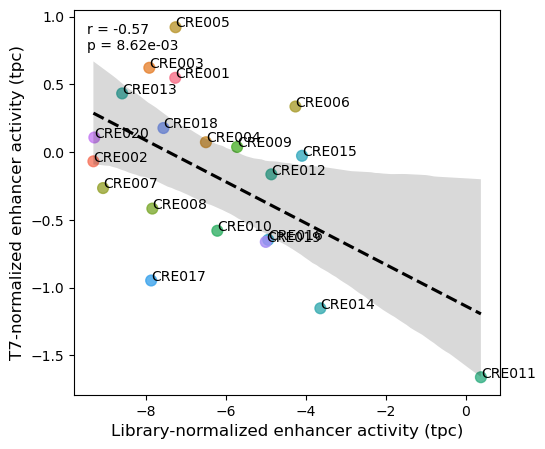

In [52]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

T7norm = np.nanmean([merged_.groupby('fov')[i].mean() for i in merged_.columns[:-3]], axis=1)
# T7norm_rep = np.nanmean([merged_rep_.groupby('fov')[i].mean() for i in merged_rep_.columns[:-3]], axis=1)

x = np.log(enh_means_df['normalized'].astype(float))
y = np.log(T7norm)

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in SFv4_T7_counts['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('T7-normalized enhancer activity (tpc)', fontsize=12)
ax.set_xlabel('Library-normalized enhancer activity (tpc)', fontsize=12)
# ax.set_title('Plasmid library bias vs T7-derived transcription')

# add labels to each point on the scatter plot
for i, txt in enumerate(SFv4_T7_counts['id']):
    ax.annotate(txt, (x[i], y[i]))


stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\T7_normalized_rep_vs_library_normalized_corr_log_250228.pdf')
plt.show()

In [475]:
# Indices of 20 test CREs for STARR-FISH from STARR-seq data
test_CREs = [0,11,4,7,9,137,186,323,515,642,1100,1086,1078,1073,1093,1101,1102,1103,1104,1105]

In [476]:
STARRseq['logFC'].loc[test_CREs]

0       5.601385
11      4.373055
4       5.032509
7       4.685353
9       4.493735
137     2.122961
186     1.903971
323     1.588704
515     1.326764
642     1.219671
1100    0.973408
1086    0.983154
1078    0.986207
1073    0.986843
1093    0.978426
1101    0.972873
1102    0.972759
1103    0.972564
1104    0.971994
1105    0.971080
Name: logFC, dtype: float64

### Correlate STARR-FISH data to bulk sequencing data

In [23]:
# Load in featureCounts table from bulk RNA-seq sample
RNAseq1 = pd.read_csv(r'C:\Users\zgibbs\cellpose\bulk_sequencing\CRE20_20240716_rep1_featureCounts_output.txt', sep = '\t', header=1)

# Change name of last column
RNAseq1 = RNAseq1.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE20_20240716_rep1/dedup.aligned_reads.bam': 'Counts'})

# Make a new column for calculated cpm of each CRE transcript
# use the total number of reads from bulk RNA-seq sample here
RNAseq1['cpm'] = (RNAseq1['Counts'].div(30262411))*1000000 

In [24]:
RNAseq1

,Geneid,Chr,Start,End,Strand,Length,Counts,cpm
0,CRE001,CRE001;CRE001,1;192,191;573,+;+,573,32039,1058.706129
1,CRE002,CRE002;CRE002,1;192,191;573,+;+,573,25692,848.973996
2,CRE003,CRE003;CRE003,1;192,191;573,+;+,573,54508,1801.178366
3,CRE004,CRE004;CRE004,1;192,191;573,+;+,573,15603,515.590116
4,CRE005,CRE005;CRE005,1;192,191;573,+;+,573,12684,419.133822
5,CRE006,CRE006;CRE006,1;192,191;573,+;+,573,1272,42.032342
6,CRE007,CRE007;CRE007,1;192,191;573,+;+,573,11373,375.812753
7,CRE008,CRE008;CRE008,1;192,191;573,+;+,573,6865,226.849077
8,CRE009,CRE009;CRE009,1;192,191;573,+;+,573,1470,48.575112
9,CRE010,CRE010;CRE010,1;192,191;573,+;+,573,823,27.195454


In [25]:
# Load in featureCounts table from bulk RNA-seq sample
RNAseq2 = pd.read_csv(r'C:\Users\zgibbs\cellpose\bulk_sequencing\CRE20_20240906_rep1_featureCounts_output.txt', sep = '\t', header=1)

# Change name of last column
RNAseq2 = RNAseq2.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE20_20240906_rep1/dedup.aligned_reads.bam': 'Counts'})

# Make a new column for calculated cpm of each CRE transcript
# use the total number of reads from bulk RNA-seq sample here
RNAseq2['cpm'] = (RNAseq2['Counts'].div(45700375))*1000000 

In [26]:
RNAseq2

,Geneid,Chr,Start,End,Strand,Length,Counts,cpm
0,CRE001,CRE001;CRE001,1;192,191;573,+;+,573,27040,591.680046
1,CRE002,CRE002;CRE002,1;192,191;573,+;+,573,24395,533.803060
2,CRE003,CRE003;CRE003,1;192,191;573,+;+,573,59550,1303.052765
3,CRE004,CRE004;CRE004,1;192,191;573,+;+,573,12399,271.310684
4,CRE005,CRE005;CRE005,1;192,191;573,+;+,573,11079,242.426895
5,CRE006,CRE006;CRE006,1;192,191;573,+;+,573,1549,33.894689
6,CRE007,CRE007;CRE007,1;192,191;573,+;+,573,13617,297.962544
7,CRE008,CRE008;CRE008,1;192,191;573,+;+,573,8311,181.858464
8,CRE009,CRE009;CRE009,1;192,191;573,+;+,573,1476,32.297328
9,CRE010,CRE010;CRE010,1;192,191;573,+;+,573,1174,25.689067


In [27]:
RNAseq1['Geneid'].values

array(['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006',
       'CRE007', 'CRE008', 'CRE009', 'CRE010', 'CRE011', 'CRE012',
       'CRE013', 'CRE014', 'CRE015', 'CRE016', 'CRE017', 'CRE018',
       'CRE019', 'CRE020'], dtype=object)

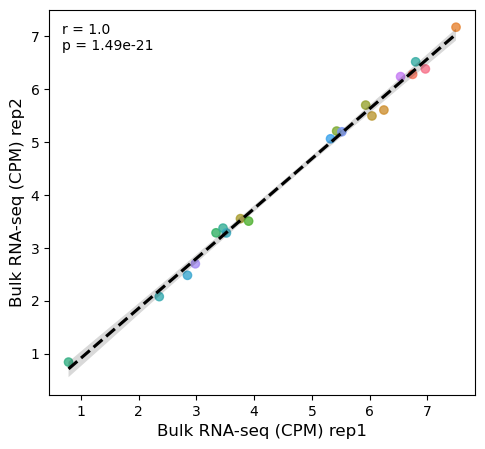

In [30]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(RNAseq1.cpm.values+1)
y = np.log(RNAseq2.cpm.values+1)

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in RNAseq1['Geneid'].values]})

ax.set_ylabel('Bulk RNA-seq (CPM) rep2', fontsize=12)
ax.set_xlabel('Bulk RNA-seq (CPM) rep1', fontsize=12)

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ_rep/figures/bulk_RNA-seq_corr_between_reps.png', dpi=600)
plt.show()

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_23308\2434605761.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  norm_CRE = merged_.groupby('fov').mean()


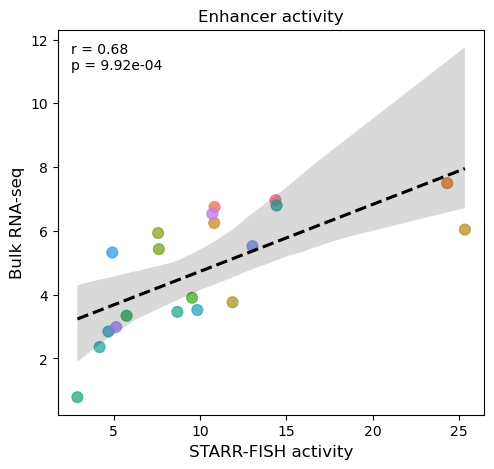

In [52]:
import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

# get the means of the raw CRE transcripts per cell
CRE = enhancer_cbg.groupby('fov').mean()
CRE_means = CRE.mean(axis=0)

# get the means of the T7-normalized transcripts per cell
norm_CRE = merged_.groupby('fov').mean()
norm_CRE_means = norm_CRE.mean(axis=0)

# x = norm_CRE_means[:20]
x = CRE_means[1:21]
# x = enhancer_full_rep1['score']
y = np.log(RNAseq1.cpm.values+1)

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in enhancer_full_rep1['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('Bulk RNA-seq', fontsize=12)
ax.set_xlabel('STARR-FISH activity', fontsize=12)
ax.set_title('Enhancer activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_Sept_2024_analysis\enhancer_activity_no_normalization_rep_pearson_corr_241003.pdf')
plt.show()

In [80]:
norm_CRE_means

CRE001                    2.753770
CRE002                    0.843377
CRE003                    1.759185
CRE004                    1.874204
CRE005                    3.698309
CRE006                    2.655518
CRE007                    1.302008
CRE008                    0.513179
CRE009                    1.849878
CRE010                    1.476203
CRE011                    0.395256
CRE012                    1.590224
CRE013                    2.070443
CRE014                    0.436802
CRE015                    2.002970
CRE016                    1.141225
CRE017                    0.113106
CRE018                    1.424308
CRE019                    1.359896
CRE020                    0.928814
total transcripts        30.188676
masks                112857.851985
dtype: float64

In [53]:
import pandas as pd

HCT116_oligos = pd.read_csv(r'C:\Users\zgibbs\cellpose\HCT116_activating_oligo.csv')

HCT116_oligos

,chr,start,end,lfc,padj
0,chr15,80003305.0,80003495.0,5.601402,3.980000e-124
1,chr15,80003185.0,80003375.0,5.445969,2.070000e-119
2,chr1,244735538.0,244735728.0,5.140302,9.600000e-111
3,chr21,33367286.0,33367476.0,5.099388,1.110000e-109
4,chr22,49384139.0,49384329.0,5.031316,1.690000e-103
...,...,...,...,...,...
1101,YFL009W_196_385,NaN,NaN,0.006862,9.663627e-01
1102,YNL186W_1584_1773,NaN,NaN,0.002139,9.842529e-01
1103,YDR490C_1052_1241,NaN,NaN,0.001636,9.862793e-01
1104,YLR138W_2138_2327,NaN,NaN,-0.001606,9.969921e-01


In [54]:
# Indices for the 20 test CREs used in STARR-FISH pilot (last 5 are yeast ORFs) from the HCT116_activating_oligos file
test_CREs = [0,11,4,7,9,137,186,323,515,642,1100,1086,1078,1073,1093,1101,1102,1103,1104,1105]

In [55]:
HCT116_oligos['lfc'].loc[test_CREs]

0       5.601402
11      4.059501
4       5.031316
7       4.536123
9       4.398186
137     1.997087
186     1.816948
323     1.515312
515     1.261200
642     1.156818
1100    0.886372
1086    0.901613
1078    0.904561
1073    0.906934
1093    0.897712
1101    0.006862
1102    0.002139
1103    0.001636
1104   -0.001606
1105   -0.003500
Name: lfc, dtype: float64

In [56]:
# get the means of the raw CRE transcripts per cell
CRE = enhancer_cbg.groupby('fov').mean()
CRE_means = CRE.mean(axis=0)

# get the means of the T7-normalized transcripts per cell
norm_CRE = merged_.groupby('fov').mean()
norm_CRE_means = norm_CRE.mean(axis=0)

# norm_CRE_rep = merged_rep_.groupby('fov').mean()
# norm_CRE_means_rep = norm_CRE_rep.mean(axis=0)

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_42916\1509167133.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  norm_CRE = merged_.groupby('fov').mean()


In [59]:
norm_CRE_means[:20]

CRE001    1.730941
CRE002    0.934845
CRE003    1.864062
CRE004    1.076202
CRE005    2.514130
CRE006    1.400670
CRE007    0.767380
CRE008    0.659509
CRE009    1.039130
CRE010    0.560021
CRE011    0.190044
CRE012    0.849175
CRE013    1.542710
CRE014    0.316079
CRE015    0.973661
CRE016    0.523817
CRE017    0.387976
CRE018    1.195100
CRE019    0.515739
CRE020    1.114433
dtype: float64

In [217]:
CRE_means_aligned = CRE_means[1:21].reset_index(drop=True)
SFv4_T7_counts_aligned = SFv4_T7_counts['counts'].reset_index(drop=True)

# Now perform the division
result = CRE_means_aligned / SFv4_T7_counts_aligned.astype(float)
print(result)

0     0.000304
1     0.000052
2     0.000185
3     0.000671
4     0.000534
5     0.012942
6     0.000082
7     0.000235
8     0.003045
9     0.001700
10    1.452255
11    0.006783
12    0.000111
13    0.024523
14    0.014939
15    0.006314
16    0.000261
17    0.000320
18    0.006040
19    0.000062
dtype: float64


In [81]:
enh_means

masks                111207.020536
CRE001                   33.313687
CRE002                   18.844432
CRE003                   48.403466
CRE004                   24.403657
CRE005                   33.625291
CRE006                   12.983374
CRE007                   10.777523
CRE008                   12.896271
CRE009                   10.327074
CRE010                    6.805629
CRE011                    2.899661
CRE012                    9.926093
CRE013                   24.267191
CRE014                    4.504583
CRE015                   10.974822
CRE016                    5.340130
CRE017                    7.278604
CRE018                   21.354530
CRE019                    5.748346
CRE020                   16.207899
total transcripts       641.764533
dtype: float64

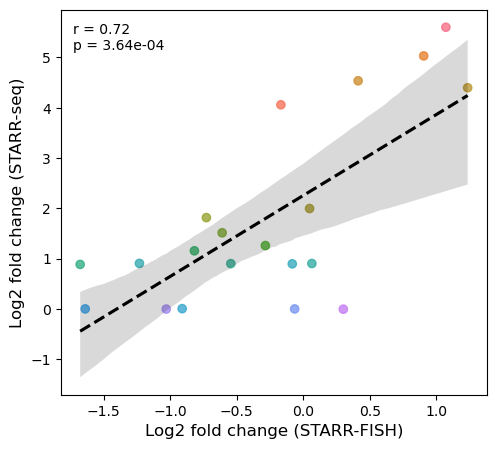

In [85]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log2(enh_means[1:21]/T7_means[1:21]) # calculcate log2 fold change for CRE/T7 to compare to STARR-seq
# x = norm_CRE_means[:20]
# x = T7_means[1:21]
# x = enhancer_full_rep1['score']
y = HCT116_oligos['lfc'].loc[test_CREs]

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in norm_CRE_means[:20].index]})

ax.set_ylabel('Log2 fold change (STARR-seq)', fontsize=12)
ax.set_xlabel('Log2 fold change (STARR-FISH)', fontsize=12)

# add labels to each point on the scatter plot
# for i, txt in enumerate(norm_CRE_means[:20].index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\log2_FC_STARR-FISH_vs_log2_FC_STARRseq_corr_250307.pdf')
plt.show()

### Try sampling smaller number of cells for linear regression: how many cells needed to measure enhancer activity?

In [137]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 1000  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean, std, and coefficient of variation for each column
        mean = subsample[col].mean()
        std_dev = subsample[col].std()
        cv = std_dev / mean if mean != 0 else np.nan  # Coefficient of variation (CV)
        
        # Store statistics for the column
        stats[f'{col}_mean'] = mean
        stats[f'{col}_std_dev'] = std_dev
        stats[f'{col}_cv'] = cv

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)

# Display the DataFrame
stats_df


,subsample,CRE001_mean,CRE001_std_dev,CRE001_cv,CRE002_mean,CRE002_std_dev,CRE002_cv,CRE003_mean,CRE003_std_dev,CRE003_cv,...,CRE017_cv,CRE018_mean,CRE018_std_dev,CRE018_cv,CRE019_mean,CRE019_std_dev,CRE019_cv,CRE020_mean,CRE020_std_dev,CRE020_cv
0,1,2.782133,5.082197,1.826726,0.844105,0.887569,1.051491,1.909031,3.667866,1.921324,...,2.195221,1.403927,1.676456,1.194119,1.335543,1.830036,1.370255,0.925162,1.206730,1.304345
1,2,3.136292,8.345951,2.661089,0.821919,0.855364,1.040692,1.916861,3.851986,2.009528,...,1.987934,1.506939,2.640112,1.751971,1.294155,1.615680,1.248444,0.941778,1.184427,1.257649
2,3,2.697687,4.843905,1.795577,0.825730,0.986648,1.194879,1.640886,2.064647,1.258251,...,2.078274,1.342242,1.572208,1.171330,1.295591,1.805071,1.393241,0.898639,1.054981,1.173976
3,4,2.345255,4.718738,2.012037,0.823626,0.872812,1.059718,1.735294,2.592300,1.493868,...,2.272999,1.329718,1.640164,1.233468,1.427327,2.046036,1.433474,0.849152,0.918799,1.082019
4,5,2.563297,4.068849,1.587350,0.857992,0.925400,1.078565,1.659785,2.717745,1.637408,...,1.833859,1.439405,2.226656,1.546928,1.407199,1.854160,1.317625,0.958059,1.436082,1.498949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,2.572471,5.247242,2.039767,0.818434,0.825979,1.009218,1.746451,2.739637,1.568688,...,2.124303,1.435189,1.878339,1.308775,1.341368,1.734432,1.293032,0.968191,1.226588,1.266887
96,97,2.756162,4.908486,1.780914,0.839036,1.057540,1.260424,1.880716,3.830331,2.036635,...,1.974905,1.481759,2.124673,1.433885,1.345252,1.807686,1.343753,0.884312,0.981104,1.109455
97,98,2.629951,4.696977,1.785956,0.823358,0.875214,1.062981,1.692482,2.367926,1.399085,...,1.987534,1.433211,1.803925,1.258660,1.364386,1.799089,1.318607,0.980020,1.385786,1.414039
98,99,2.874154,5.723943,1.991523,0.857084,1.017343,1.186982,1.792852,3.290449,1.835315,...,2.221642,1.479201,2.492379,1.684949,1.344413,1.676974,1.247365,0.903284,1.310019,1.450284


### Subsampling the T7-normalized data

In [193]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 5000  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df5000 = stats_df

df5000 = df5000.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df5000

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.729741,2.770390,2.648028,2.063935,1.995531,1.894832,1.856737,1.788966,1.582305,1.507962,...,1.360864,1.307809,1.149726,0.926367,0.842273,0.516503,0.430050,0.394447,0.110399,1.0
1,3.673280,2.794244,2.711334,2.080914,1.976212,1.829695,1.826290,1.793441,1.581152,1.466572,...,1.328155,1.306099,1.131594,0.935735,0.845601,0.524375,0.438410,0.395316,0.113021,2.0
2,3.677840,2.777155,2.610399,2.047692,1.995817,1.880913,1.852907,1.792051,1.579924,1.506266,...,1.373050,1.288598,1.152011,0.935526,0.839392,0.517358,0.435292,0.396862,0.112983,3.0
3,3.647526,2.698525,2.609349,2.082725,2.026388,1.837841,1.837965,1.743652,1.569407,1.486053,...,1.367599,1.309757,1.144256,0.922574,0.856243,0.531877,0.440570,0.393600,0.112117,4.0
4,3.704051,2.842914,2.687008,2.092508,2.013182,1.917956,1.884510,1.765174,1.605824,1.461251,...,1.379569,1.348779,1.175351,0.910713,0.843011,0.512029,0.429625,0.389079,0.110327,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.768037,2.763980,2.679227,2.056749,1.990482,1.853657,1.839779,1.784075,1.583394,1.465832,...,1.349358,1.322073,1.144873,0.956193,0.854880,0.525890,0.435418,0.391369,0.114511,499.0
499,3.805026,2.770389,2.707891,2.075385,2.019443,1.849338,1.868851,1.798797,1.603643,1.458145,...,1.356760,1.267372,1.122145,0.924243,0.846503,0.520143,0.429561,0.398918,0.111360,500.0
avg,3.699601,2.755633,2.653831,2.068882,2.002995,1.871618,1.846025,1.763710,1.590102,1.473691,...,1.359477,1.301386,1.139829,0.929509,0.844205,0.514499,0.435950,0.394626,0.112909,NaN
std_dev,0.056088,0.056355,0.041058,0.027604,0.024706,0.027078,0.024719,0.028983,0.019581,0.019950,...,0.017952,0.018130,0.013174,0.012448,0.009050,0.008933,0.005661,0.006018,0.002208,NaN


In [194]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 2500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df2500 = stats_df

df2500 = df2500.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df2500

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.782476,2.774160,2.646570,2.045466,1.993097,1.934694,1.888071,1.827813,1.588435,1.483478,...,1.361276,1.321686,1.166738,0.934459,0.841668,0.515859,0.419487,0.400895,0.107733,1.0
1,3.735693,3.054208,2.787426,2.089154,1.997393,1.915844,1.876222,1.885219,1.612135,1.502241,...,1.374905,1.331368,1.125747,0.957215,0.856298,0.527921,0.441663,0.405098,0.115179,2.0
2,3.620167,2.784108,2.658061,2.050672,1.982987,1.838677,1.831386,1.750455,1.593031,1.518366,...,1.376718,1.276323,1.187169,0.946353,0.843913,0.516531,0.451049,0.400044,0.113587,3.0
3,3.510563,2.512996,2.501048,2.030580,1.973658,1.773055,1.801890,1.718291,1.560445,1.481500,...,1.354398,1.265110,1.137591,0.910803,0.853333,0.528394,0.425344,0.391255,0.116356,4.0
4,3.595972,2.748186,2.742318,2.101400,2.065085,1.818284,1.914583,1.738779,1.634204,1.444432,...,1.370456,1.333310,1.161620,0.917148,0.848816,0.515857,0.430436,0.388476,0.105190,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.785332,2.727354,2.705654,2.034307,1.976183,1.856431,1.834494,1.828276,1.555607,1.495974,...,1.334163,1.352717,1.146353,0.975442,0.868921,0.543510,0.440408,0.385889,0.118404,499.0
499,3.801258,2.909776,2.807542,2.090387,2.051157,1.857641,1.931281,1.817307,1.642394,1.444278,...,1.396189,1.302401,1.144103,0.916279,0.844703,0.509130,0.434544,0.410458,0.113633,500.0
avg,3.699036,2.757610,2.655328,2.069979,2.003193,1.873820,1.845453,1.764689,1.590886,1.473358,...,1.359493,1.301232,1.140078,0.930903,0.844527,0.514922,0.435980,0.394240,0.112911,NaN
std_dev,0.095153,0.096698,0.073877,0.048926,0.042535,0.045547,0.042923,0.051962,0.035484,0.034956,...,0.031411,0.032434,0.022832,0.021600,0.017388,0.015690,0.009694,0.010858,0.004119,NaN


In [195]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 1000  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df1000 = stats_df

df1000 = df1000.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df1000

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.602017,2.782133,2.569617,2.091508,1.905684,1.817154,1.872994,1.909031,1.555805,1.477152,...,1.335543,1.278888,1.155680,0.925162,0.844105,0.511428,0.408878,0.389078,0.110076,1.0
1,3.769715,3.136292,2.753008,2.063387,1.921884,1.804316,1.814672,1.916861,1.647857,1.477751,...,1.294155,1.342413,1.095830,0.941778,0.821919,0.504124,0.447036,0.395229,0.115743,2.0
2,3.601978,2.697687,2.478665,1.972463,1.904956,1.831723,1.833320,1.640886,1.571974,1.418305,...,1.295591,1.205614,1.169649,0.898639,0.825730,0.478772,0.427291,0.370201,0.105382,3.0
3,3.503256,2.345255,2.589643,2.029257,2.060254,1.737834,1.797899,1.735294,1.574959,1.532508,...,1.427327,1.290847,1.142488,0.849152,0.823626,0.511052,0.422635,0.385744,0.107745,4.0
4,3.536834,2.563297,2.872019,2.108754,2.029568,1.761512,1.838297,1.659785,1.694954,1.439701,...,1.407199,1.372920,1.183294,0.958059,0.857992,0.524063,0.433124,0.396630,0.103831,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.768545,2.920414,2.705757,2.038541,1.945771,1.946242,1.816791,1.716803,1.560655,1.523545,...,1.383760,1.412893,1.175526,0.987846,0.842473,0.539688,0.455882,0.396386,0.120609,499.0
499,3.750800,2.840787,2.763957,2.132049,2.050880,1.827572,1.862825,1.875583,1.603396,1.450974,...,1.377737,1.330201,1.140045,0.948999,0.849482,0.511841,0.465567,0.428404,0.118342,500.0
avg,3.699919,2.765618,2.664695,2.070724,2.005912,1.879415,1.853014,1.765884,1.597629,1.475747,...,1.359205,1.304055,1.140722,0.932436,0.844636,0.514485,0.436359,0.395678,0.112833,NaN
std_dev,0.160687,0.163432,0.127283,0.090436,0.078682,0.079451,0.079676,0.092497,0.064647,0.059617,...,0.053969,0.053026,0.040125,0.037766,0.029665,0.029003,0.018003,0.019628,0.006984,NaN


In [196]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df500 = stats_df

df500 = df500.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df500

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.647706,2.591506,2.499330,2.116124,1.942452,1.707693,1.866162,1.986075,1.555444,1.537952,...,1.429147,1.269398,1.166243,0.979912,0.819011,0.523382,0.415579,0.409837,0.107953,1.0
1,3.676487,3.485097,2.685718,2.072653,1.891790,1.738404,1.870456,1.850561,1.663781,1.408385,...,1.325073,1.349838,1.056000,0.881206,0.835619,0.489687,0.409131,0.399371,0.099673,2.0
2,3.563189,2.532701,2.453138,2.036836,1.902928,1.917893,1.771919,1.748446,1.565317,1.439654,...,1.279875,1.200275,1.181491,0.946048,0.872717,0.511381,0.402766,0.342011,0.105127,3.0
3,3.765784,2.462578,2.647179,2.096150,2.063301,1.869849,1.849908,1.754264,1.640679,1.564931,...,1.473077,1.300572,1.194906,0.828821,0.788686,0.466014,0.419639,0.392727,0.089876,4.0
4,3.128534,2.451152,2.813527,2.043697,2.032484,1.673502,1.776435,1.683700,1.720300,1.399228,...,1.412546,1.348369,1.127982,0.926745,0.861221,0.545718,0.444510,0.389151,0.108572,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.897509,2.983406,2.914815,2.207360,2.172034,2.062518,2.030923,1.884131,1.688656,1.437035,...,1.414784,1.478060,1.168309,1.039211,0.910072,0.570723,0.451489,0.406718,0.118361,499.0
499,3.897964,2.737509,2.573926,1.976141,1.965822,1.893615,1.817542,1.677995,1.595416,1.430181,...,1.370462,1.285504,1.185045,0.939971,0.825009,0.485436,0.473919,0.407038,0.113766,500.0
avg,3.707628,2.770744,2.652411,2.067607,2.005412,1.883966,1.850317,1.774103,1.593978,1.472318,...,1.359737,1.301691,1.137012,0.931365,0.844330,0.515372,0.435426,0.394740,0.112501,NaN
std_dev,0.234953,0.254656,0.186816,0.123989,0.112322,0.120195,0.120177,0.138693,0.094870,0.085782,...,0.079497,0.076449,0.056229,0.053521,0.042114,0.040634,0.025870,0.027705,0.009747,NaN


In [197]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 250  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df250 = stats_df

df250 = df250.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df250

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.556485,2.511980,2.335695,2.057656,1.947938,1.586132,1.833425,1.964165,1.458349,1.616960,...,1.462982,1.184106,1.134551,0.945621,0.797332,0.504194,0.414246,0.443509,0.104689,1.0
1,3.408136,4.167603,2.600509,2.127998,1.904585,1.820996,1.963172,1.867406,1.593052,1.580560,...,1.398065,1.473930,1.102880,0.931287,0.863964,0.540458,0.458989,0.398137,0.107656,2.0
2,3.533904,2.913814,2.533876,2.002882,2.018294,1.849923,1.868227,1.671155,1.606991,1.415971,...,1.321832,1.131121,1.134339,0.893620,0.841479,0.438047,0.424437,0.333009,0.110521,3.0
3,3.881348,2.423723,2.898249,1.964772,2.135865,1.989244,2.031235,1.585414,1.684089,1.607764,...,1.560086,1.257017,1.212258,0.762174,0.767266,0.458590,0.379554,0.393697,0.072754,4.0
4,3.243869,2.532389,3.065286,2.114159,2.163871,1.709105,1.740896,1.758689,1.717188,1.438263,...,1.406952,1.284020,1.166861,0.916340,0.929482,0.576548,0.458704,0.361040,0.119082,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,3.843839,2.547216,2.445379,2.339771,1.762678,1.889456,1.823827,1.929892,1.461536,1.287820,...,1.362387,1.360106,1.095153,1.029756,0.939638,0.605640,0.391628,0.363817,0.111874,499.0
499,3.779390,2.474446,2.416034,2.089549,1.919273,1.774829,1.715205,1.616902,1.518039,1.461073,...,1.371084,1.273407,1.178596,0.983363,0.858903,0.500343,0.457592,0.414097,0.110809,500.0
avg,3.693505,2.772896,2.651305,2.061978,2.002394,1.890225,1.849922,1.770629,1.591401,1.472415,...,1.357887,1.302240,1.137236,0.932362,0.844645,0.515217,0.436213,0.394555,0.112702,NaN
std_dev,0.335916,0.367590,0.265356,0.188516,0.156191,0.173799,0.171675,0.192288,0.132150,0.123477,...,0.115223,0.115206,0.078881,0.076200,0.059080,0.059314,0.038023,0.041355,0.012942,NaN


In [198]:
import pandas as pd
import numpy as np

# Parameters
n_subsamples = 500  # Number of subsamples
subsample_size = 100  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in range(n_subsamples):
    # Randomly sample without replacement
    subsample = merged_.iloc[:,:20].sample(n=subsample_size, random_state=i)
    
    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for col in merged_.columns[:20]:
        # Calculate mean for each column
        mean = subsample[col].mean()
        
        # Store statistics for the column
        stats[col] = mean

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe
stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df100 = stats_df

df100 = df100.sort_values('avg', axis=1, ascending=False)
# Display the DataFrame
df100

,CRE005,CRE001,CRE006,CRE013,CRE015,CRE004,CRE009,CRE003,CRE012,CRE010,...,CRE019,CRE007,CRE016,CRE020,CRE002,CRE008,CRE014,CRE011,CRE017,subsample
0,3.664399,2.351005,2.124605,1.802563,1.673645,1.542983,1.585319,1.541869,1.289925,1.938329,...,1.524783,1.262545,1.099741,0.868738,0.705394,0.350650,0.403225,0.501499,0.111194,1.0
1,3.632679,3.324782,1.741430,2.311368,1.721529,1.389765,1.541991,1.793046,1.236176,1.469254,...,1.038064,1.645263,0.942098,0.916298,0.811791,0.519275,0.484321,0.347785,0.106978,2.0
2,3.138836,3.010542,2.169542,1.783925,1.587579,1.837678,1.486320,1.723203,1.604235,1.510884,...,1.308810,1.131363,0.972850,0.892620,0.760616,0.419633,0.468046,0.391019,0.092345,3.0
3,4.256268,2.535196,3.561261,1.997395,2.291318,1.802979,2.148776,1.477837,1.878634,1.718792,...,1.500286,1.450152,1.285766,0.861474,0.769459,0.572749,0.413737,0.374330,0.083242,4.0
4,3.108868,2.705580,2.169035,2.167068,1.962450,1.911854,1.590199,2.011219,1.558652,1.445244,...,1.610699,1.331145,1.223657,0.971411,0.917725,0.526934,0.402131,0.322744,0.109478,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,2.946852,2.669852,2.687074,2.267376,1.912923,1.756540,1.894494,1.999685,1.442491,1.357531,...,1.388463,1.478890,1.139855,1.221576,0.938928,0.669851,0.408765,0.444514,0.129457,499.0
499,4.102592,2.644689,2.317126,1.937630,1.837713,1.663015,1.693691,1.593389,1.563051,1.391256,...,1.237785,1.236658,1.021955,0.878912,0.876081,0.399887,0.439767,0.350356,0.109945,500.0
avg,3.692243,2.767096,2.635106,2.053210,1.999659,1.884263,1.852803,1.764495,1.586095,1.468088,...,1.355708,1.293600,1.134558,0.937235,0.842103,0.513928,0.439029,0.392138,0.112809,NaN
std_dev,0.541935,0.571110,0.434181,0.300242,0.250571,0.281041,0.269668,0.291264,0.204786,0.191116,...,0.179645,0.180749,0.129862,0.126109,0.092351,0.092273,0.061713,0.067014,0.022026,NaN


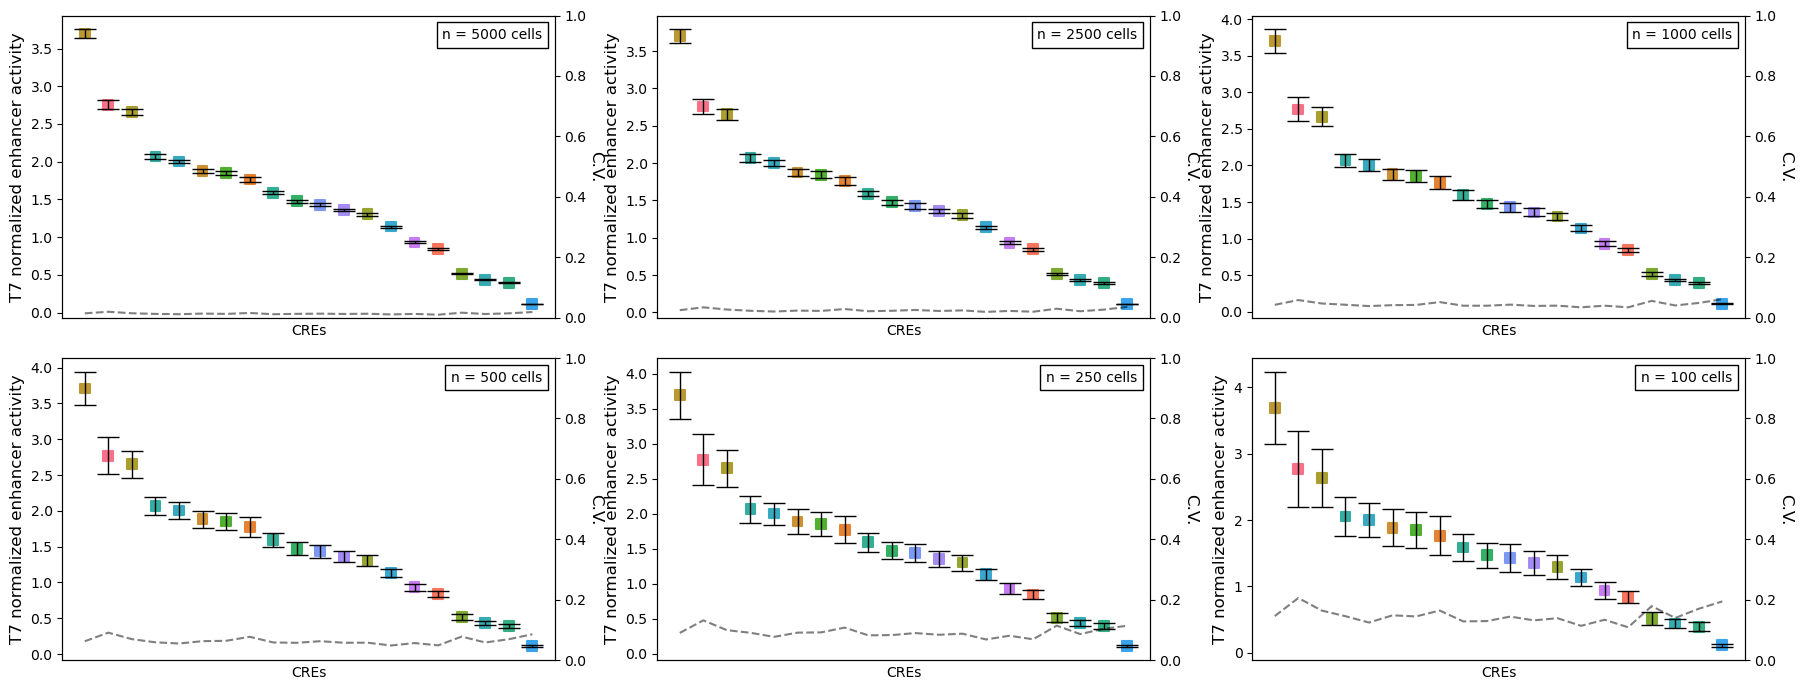

In [201]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# List of DataFrames and their corresponding names
dataframes = [df5000, df2500, df1000, df500, df250, df100]
df_names = ['5000 cells', '2500 cells', '1000 cells', '500 cells', '250 cells', '100 cells']

# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(18, 7))

# Loop through DataFrames and plot each
for i, (df, name) in enumerate(zip(dataframes, df_names)):
    row, col = divmod(i, 3)  # Calculate row and column index for the subplot
    ax = axs[row, col]
    
    # Scatter plot with error bars
    ax.scatter(range(0, 20), df.iloc[-3,:20], marker='s', c=[colors[i] for i in df.columns[:20]], s=50, lw=1.5)
    ax.errorbar(range(0, 20), df.iloc[-3,:20], df.iloc[-2,:20], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
    ax.set_ylabel('T7 normalized enhancer activity', fontsize=12)
    ax.set_xlabel('CREs')
    ax.set_xticks([])
    
    # Create twin axis for CV plot
    ax_twin = ax.twinx()
    ax_twin.plot(range(0, 20), df.iloc[-1,:20], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
    ax_twin.set_ylim(0, 1)
    ax_twin.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)
    
    # Add annotation for the number of cells
    anchored_text = AnchoredText(f"n = {name}", loc=1)
    ax.add_artist(anchored_text)

# Adjust the layout to prevent overlap
plt.tight_layout()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\downsampling_T7_normalized_250131.pdf')

# Show the plot
plt.show()

In [305]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=100)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df100 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df100['stdev'] = df100.std(axis=1)
df100['avg'] = df100[df100.columns[:10]].mean(axis=1)
df100['CV'] = df100.stdev/df100.avg
d100 = df100.sort_values('avg', axis=0, ascending=False)

In [214]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged_.sample(n=5000)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df5000 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df5000['stdev'] = df5000.std(axis=1)
df5000['avg'] = df5000[df5000.columns[:10]].mean(axis=1)
df5000['CV'] = df5000.stdev/df5000.avg
d5000 = df5000.sort_values('avg', axis=0, ascending=False)

In [215]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged_.sample(n=2500)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df2500 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df2500['stdev'] = df2500.std(axis=1)
df2500['avg'] = df2500[df2500.columns[:10]].mean(axis=1)
df2500['CV'] = df2500.stdev/df2500.avg
d2500 = df2500.sort_values('avg', axis=0, ascending=False)

In [216]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged_.sample(n=1000)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df1000 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df1000['stdev'] = df1000.std(axis=1)
df1000['avg'] = df1000[df1000.columns[:10]].mean(axis=1)
df1000['CV'] = df1000.stdev/df1000.avg
d1000 = df1000.sort_values('avg', axis=0, ascending=False)

In [217]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged_.sample(n=500)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df500 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df500['stdev'] = df500.std(axis=1)
df500['avg'] = df500[df500.columns[:10]].mean(axis=1)
df500['CV'] = df500.stdev/df500.avg
d500 = df500.sort_values('avg', axis=0, ascending=False)

In [218]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged_.sample(n=250)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df250 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df250['stdev'] = df250.std(axis=1)
df250['avg'] = df250[df250.columns[:10]].mean(axis=1)
df250['CV'] = df250.stdev/df250.avg
d250 = df250.sort_values('avg', axis=0, ascending=False)

In [219]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged_.sample(n=100)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df100 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df100['stdev'] = df100.std(axis=1)
df100['avg'] = df100[df100.columns[:10]].mean(axis=1)
df100['CV'] = df100.stdev/df100.avg
d100 = df100.sort_values('avg', axis=0, ascending=False)

In [ ]:
# Plot the T7 normalized enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, axs = plt.subplots(2, 3, figsize=(18,7))

axs[0,0].scatter(range(0,20), d2000['avg'], marker='s', c=[colors[i] for i in d2000.index], s=50, lw=1.5)
axs[0,0].errorbar(range(0,20), d2000['avg'], d2000['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,0].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,0].set_xlabel('CREs')
axs[0,0].set_xticks([])
# axs[0,0].set_title('2500 cells')

ax1 = axs[0, 0].twinx()
ax1.plot(range(0,20), d2000['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax1.set_ylim(0,1)
ax1.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[0,1].scatter(range(0,20), d5000['avg'], marker='s', c=[colors[i] for i in d5000.index], s=50, lw=1.5)
axs[0,1].errorbar(range(0,20), d5000['avg'], d5000['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,1].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,1].set_xlabel('CREs')
axs[0,1].set_xticks([])
# axs[1,0].set_title('1000 cells')

ax2 = axs[0,1].twinx()
ax2.plot(range(0,20), d5000['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax2.set_ylim(0,1)
ax2.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[0,2].scatter(range(0,20), d500['avg'], marker='s', c=[colors[i] for i in d500.index], s=50, lw=1.5)
axs[0,2].errorbar(range(0,20), d500['avg'], d500['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,2].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,2].set_xlabel('CREs')
axs[0,2].set_xticks([])
# axs[2,0].set_title('500 cells')

ax3 = axs[0,2].twinx()
ax3.plot(range(0,20), d500['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax3.set_ylim(0,1)
ax3.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,0].scatter(range(0,20), d250['avg'], marker='s', c=[colors[i] for i in d250.index], s=50, lw=1.5)
axs[1,0].errorbar(range(0,20), d250['avg'], d250['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,0].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,0].set_xlabel('CREs')
axs[1,0].set_xticks([])
# axs[0,1].set_title('250 cells')

ax4 = axs[1,0].twinx()
ax4.plot(range(0,20), d250['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax4.set_ylim(0,1)
ax4.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,1].scatter(range(0,20), d100['avg'], marker='s', c=[colors[i] for i in d100.index], s=50, lw=1.5)
axs[1,1].errorbar(range(0,20), d100['avg'], d100['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,1].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,1].set_xlabel('CREs')
axs[1,1].set_xticks([])
# axs[1,1].set_title('100 cells')

ax5 = axs[1, 1].twinx()
ax5.plot(range(0,20), d100['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax5.set_ylim(0,1)
ax5.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,2].scatter(range(0,20), d50['avg'], marker='s', c=[colors[i] for i in d50.index], s=50, lw=1.5)
axs[1,2].errorbar(range(0,20), d50['avg'], d50['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,2].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,2].set_xlabel('CREs')
axs[1,2].set_xticks([])
# axs[2,1].set_title('50 cells')

ax6 = axs[1,2].twinx()
ax6.plot(range(0,20), d50['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax6.set_ylim(0,1)
ax6.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

anchored_text1 = AnchoredText(f"n = 2000 cells", loc=1)
axs[0,0].add_artist(anchored_text1)
anchored_text2 = AnchoredText(f"n = 1000 cells", loc=1)
axs[0,1].add_artist(anchored_text2)
anchored_text3 = AnchoredText(f"n = 500 cells", loc=1)
axs[0,2].add_artist(anchored_text3)

anchored_text4 = AnchoredText(f"n = 250 cells", loc=1)
axs[1,0].add_artist(anchored_text4)
anchored_text5 = AnchoredText(f"n = 100 cells", loc=1)
axs[1,1].add_artist(anchored_text5)
anchored_text6 = AnchoredText(f"n = 50 cells", loc=1)
axs[1,2].add_artist(anchored_text6)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\downsampling_T7_normalized_240806.pdf')
plt.show()

In [307]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=250)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df250 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df250['stdev'] = df250.std(axis=1)
df250['avg'] = df250[df250.columns[:10]].mean(axis=1)
df250['CV'] = df250.stdev/df250.avg
d250 = df250.sort_values('avg', axis=0, ascending=False)

In [300]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=500)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df500 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df500['stdev'] = df500.std(axis=1)
df500['avg'] = df500[df500.columns[:10]].mean(axis=1)
df500['CV'] = df500.stdev/df500.avg
d500 = df500.sort_values('avg', axis=0, ascending=False)

In [301]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=1000)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df1000 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df1000['stdev'] = df1000.std(axis=1)
df1000['avg'] = df1000[df1000.columns[:10]].mean(axis=1)
df1000['CV'] = df1000.stdev/df1000.avg
d1000 = df1000.sort_values('avg', axis=0, ascending=False)

In [302]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=2000)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df2000 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df2000['stdev'] = df2000.std(axis=1)
df2000['avg'] = df2000[df2000.columns[:10]].mean(axis=1)
df2000['CV'] = df2000.stdev/df2000.avg
d2000 = df2000.sort_values('avg', axis=0, ascending=False)

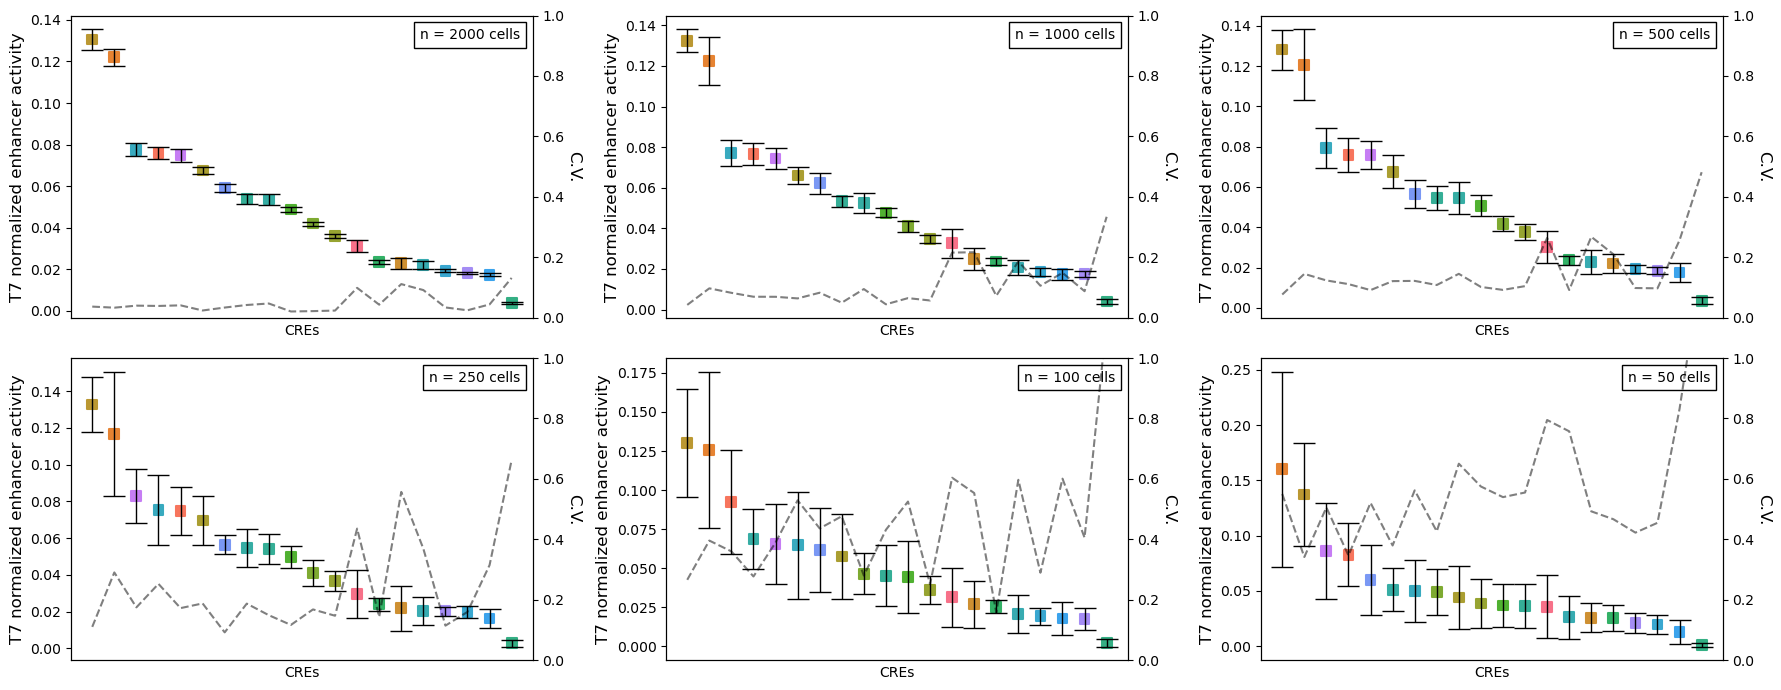

In [309]:
# Plot the T7 normalized enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, axs = plt.subplots(2, 3, figsize=(18,7))

axs[0,0].scatter(range(0,20), d2000['avg'], marker='s', c=[colors[i] for i in d2000.index], s=50, lw=1.5)
axs[0,0].errorbar(range(0,20), d2000['avg'], d2000['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,0].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,0].set_xlabel('CREs')
axs[0,0].set_xticks([])
# axs[0,0].set_title('2500 cells')

ax1 = axs[0, 0].twinx()
ax1.plot(range(0,20), d2000['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax1.set_ylim(0,1)
ax1.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[0,1].scatter(range(0,20), d1000['avg'], marker='s', c=[colors[i] for i in d1000.index], s=50, lw=1.5)
axs[0,1].errorbar(range(0,20), d1000['avg'], d1000['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,1].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,1].set_xlabel('CREs')
axs[0,1].set_xticks([])
# axs[1,0].set_title('1000 cells')

ax2 = axs[0,1].twinx()
ax2.plot(range(0,20), d1000['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax2.set_ylim(0,1)
ax2.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[0,2].scatter(range(0,20), d500['avg'], marker='s', c=[colors[i] for i in d500.index], s=50, lw=1.5)
axs[0,2].errorbar(range(0,20), d500['avg'], d500['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,2].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,2].set_xlabel('CREs')
axs[0,2].set_xticks([])
# axs[2,0].set_title('500 cells')

ax3 = axs[0,2].twinx()
ax3.plot(range(0,20), d500['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax3.set_ylim(0,1)
ax3.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,0].scatter(range(0,20), d250['avg'], marker='s', c=[colors[i] for i in d250.index], s=50, lw=1.5)
axs[1,0].errorbar(range(0,20), d250['avg'], d250['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,0].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,0].set_xlabel('CREs')
axs[1,0].set_xticks([])
# axs[0,1].set_title('250 cells')

ax4 = axs[1,0].twinx()
ax4.plot(range(0,20), d250['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax4.set_ylim(0,1)
ax4.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,1].scatter(range(0,20), d100['avg'], marker='s', c=[colors[i] for i in d100.index], s=50, lw=1.5)
axs[1,1].errorbar(range(0,20), d100['avg'], d100['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,1].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,1].set_xlabel('CREs')
axs[1,1].set_xticks([])
# axs[1,1].set_title('100 cells')

ax5 = axs[1, 1].twinx()
ax5.plot(range(0,20), d100['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax5.set_ylim(0,1)
ax5.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,2].scatter(range(0,20), d50['avg'], marker='s', c=[colors[i] for i in d50.index], s=50, lw=1.5)
axs[1,2].errorbar(range(0,20), d50['avg'], d50['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,2].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,2].set_xlabel('CREs')
axs[1,2].set_xticks([])
# axs[2,1].set_title('50 cells')

ax6 = axs[1,2].twinx()
ax6.plot(range(0,20), d50['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax6.set_ylim(0,1)
ax6.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

anchored_text1 = AnchoredText(f"n = 2000 cells", loc=1)
axs[0,0].add_artist(anchored_text1)
anchored_text2 = AnchoredText(f"n = 1000 cells", loc=1)
axs[0,1].add_artist(anchored_text2)
anchored_text3 = AnchoredText(f"n = 500 cells", loc=1)
axs[0,2].add_artist(anchored_text3)

anchored_text4 = AnchoredText(f"n = 250 cells", loc=1)
axs[1,0].add_artist(anchored_text4)
anchored_text5 = AnchoredText(f"n = 100 cells", loc=1)
axs[1,1].add_artist(anchored_text5)
anchored_text6 = AnchoredText(f"n = 50 cells", loc=1)
axs[1,2].add_artist(anchored_text6)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\downsampling_T7_normalized_240806.pdf')
plt.show()